# Problem 3 — Discount & Pricing Analysis
**Datahut Data Science Internship Assignment — adidas India Men's Footwear**

Uses `products_clean.csv` (from Problem 2) to answer commercial questions about how adidas prices and discounts its Men's Footwear catalogue.

**Sections:** Overview → Sub-brand comparison → Price tier vs discount → Outlier flagging → Charts → Client write-up


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("products_clean.csv")
print(f"Rows: {len(df)}, Columns: {list(df.columns)}")
df.head()

Rows: 1671, Columns: ['product_id', 'name', 'sub_brand', 'url', 'sale_price', 'mrp', 'discount_amount', 'discount_pct']


,product_id,name,sub_brand,url,sale_price,mrp,discount_amount,discount_pct
0,B75806,Samba OG Shoes,Originals,https://www.adidas.co.in/samba-og-shoes/B75806...,10999.0,10999,0.0,0.0
1,ID8757,Galaxy 7 Running Shoes,Performance,https://www.adidas.co.in/galaxy-7-running-shoe...,4409.5,6299,1889.5,30.0
2,B75807,Samba OG Shoes,Originals,https://www.adidas.co.in/samba-og-shoes/B75807...,10999.0,10999,0.0,0.0
3,KI0066,PURECHILL SLIDES,Sportswear,https://www.adidas.co.in/purechill-slides/KI00...,6599.0,6599,0.0,0.0
4,JH6206,Adizero EVO SL Shoes,Performance,https://www.adidas.co.in/adizero-evo-sl-shoes/...,15999.0,15999,0.0,0.0


## 1. Catalogue & Discount Overview

In [21]:
on_sale_mask = df["discount_amount"] > 0
n_total      = len(df)
n_on_sale    = on_sale_mask.sum()
n_full_price = n_total - n_on_sale

print(f"Total products: {n_total}")
print(f"On sale:        {n_on_sale}  ({n_on_sale/n_total:.1%})")
print(f"Full price:     {n_full_price}  ({n_full_price/n_total:.1%})")

Total products: 1671
On sale:        1400  (83.8%)
Full price:     271  (16.2%)


In [22]:
# Stats for discounted products only
# Full-price items excluded — including them would create a misleading spike at 0%
discounted = df[on_sale_mask]
print("discount_pct stats (discounted products only):")
discounted["discount_pct"].describe()

discount_pct stats (discounted products only):


count    1400.000000
mean       44.907143
std         8.148371
min        30.000000
25%        40.000000
50%        50.000000
75%        50.000000
max        60.000000
Name: discount_pct, dtype: float64

In [23]:
# Do discounts cluster at specific values?
value_counts = discounted["discount_pct"].value_counts().sort_index()
print("Discount % value counts:")
print(value_counts)

Discount % value counts:
discount_pct
30.0    283
35.0      4
40.0    146
50.0    962
60.0      5
Name: count, dtype: int64


**Finding:** Discounts are strongly grouped at **30%, 40%, and 50%**, with **50% being the most common discount**.

This suggests that adidas uses a few standard discount levels across its products instead of setting a different discount for every product.



In [24]:
# Summary stats for the whole catalogue
df[["mrp", "sale_price", "discount_pct"]].describe()

,mrp,sale_price,discount_pct
count,1671.000000,1671.000000,1671.000000
mean,6839.813884,4426.170856,37.624177
std,3629.737168,3263.760167,18.160429
min,999.000000,649.500000,0.000000
25%,4599.000000,2399.500000,30.000000
50%,5599.000000,3299.000000,50.000000
75%,8599.000000,5499.500000,50.000000
max,34999.000000,34999.000000,60.000000


## 2. Which Sub-brands Discount Hardest?

In [25]:
sub_brand_summary = df.groupby("sub_brand").agg(
    n_products          = ("product_id", "count"),
    n_on_sale           = ("discount_amount", lambda x: (x > 0).sum()),
    median_discount_pct = ("discount_pct", "median"),
    mean_discount_pct   = ("discount_pct", "mean"),
    avg_mrp             = ("mrp", "mean"),
    avg_sale            = ("sale_price", "mean"),
).reset_index()

sub_brand_summary["pct_on_sale"] = (
    sub_brand_summary["n_on_sale"] / sub_brand_summary["n_products"] * 100
).round(1)

sub_brand_summary["avg_saving"] = sub_brand_summary["avg_mrp"] - sub_brand_summary["avg_sale"]

sub_brand_summary.sort_values("median_discount_pct", ascending=False)

,sub_brand,n_products,n_on_sale,median_discount_pct,mean_discount_pct,avg_mrp,avg_sale,pct_on_sale,avg_saving
1,Performance,858,752,50.0,39.580420,6870.794872,4349.148601,87.6,2521.646270
2,Sportswear,536,451,50.0,38.899254,5710.194030,3421.492537,84.1,2288.701493
3,TERREX,77,72,50.0,41.688312,5056.142857,2933.493506,93.5,2122.649351
0,Originals,200,125,30.0,24.250000,10421.000000,8023.815000,62.5,2397.185000


**Findings:**
* Originals is discounted less aggressively than the other sub-brands. Its median discount is 30%, and 62.5% of products are on sale.
* Performance, Sportswear, and TERREX have a median discount of 50%. TERREX has the highest share of discounted products at 93.5%.
* This suggests that Originals follows a more conservative discounting pattern than the other sub-brands.

_Note: This analysis is based on a single snapshot, so discount patterns may change with seasons or sale events._


## 3. Price Tier vs Discount Depth

In [26]:
# Quartile-based price tiers — used because MRP is right-skewed.
# Quartiles give evenly-populated groups, making comparisons fairer than fixed bands.
df["price_tier"] = pd.qcut(df["mrp"], q=4, labels=["Low", "Mid", "High", "Premium"])

tier_summary = df.groupby("price_tier", observed=True).agg(
    n_products          = ("product_id", "count"),
    price_range_min     = ("mrp", "min"),
    price_range_max     = ("mrp", "max"),
    median_discount_pct = ("discount_pct", "median"),
    pct_on_sale         = ("discount_amount", lambda x: (x > 0).mean() * 100),
).round(1)

tier_summary

,n_products,price_range_min,price_range_max,median_discount_pct,pct_on_sale
price_tier,,,,,
Low,468,999,4599,50.0,85.7
Mid,400,4799,5599,50.0,91.5
High,416,5999,8599,50.0,85.8
Premium,387,8999,34999,30.0,71.3


In [27]:
# Pearson correlation between MRP and discount_pct
corr, p_value = stats.pearsonr(df["mrp"], df["discount_pct"])
print(f"Pearson r (MRP vs discount_pct): {corr:.3f}")
print(f"p-value: {p_value:.4f}")

Pearson r (MRP vs discount_pct): -0.242
p-value: 0.0000


**Conclusion:**
* There is a **weak negative relationship** between price and discount percentage (**r = -0.242**).
* This means higher-priced shoes tend to receive slightly smaller discounts. However, the relationship is weak, so price alone is not a strong predictor of discount depth.
* The very small p-value shows that the relationship is statistically significant, but its actual strength is still weak.

## 4. Flag Pricing Outliers

**Method: IQR fences, computed within each sub-brand group** (not the whole catalogue).

**Why within sub-brand?** Comparing a ₹2,000 Sportswear shoe against a ₹15,000 Originals collab is not fair — they follow different pricing strategies. Computing fences within sub-brand means a flagged item is genuinely unusual *for its own category*. Standard Tukey fence: `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]`.


In [28]:
def flag_outliers_iqr(group):
    q1    = group["discount_pct"].quantile(0.25)
    q3    = group["discount_pct"].quantile(0.75)
    iqr   = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    group["is_outlier"]          = (group["discount_pct"] < lower) | (group["discount_pct"] > upper)
    group["outlier_lower_fence"] = lower
    group["outlier_upper_fence"] = upper
    return group

df = df.groupby("sub_brand", group_keys=False).apply(
    flag_outliers_iqr, include_groups=False
).join(df[["sub_brand"]])

outliers = df[df["is_outlier"]].copy()
print(f"Flagged outliers: {len(outliers)} / {len(df)} products ({len(outliers)/len(df):.1%})")

Flagged outliers: 0 / 1671 products (0.0%)


In [29]:
def reason(row):
    if row["discount_pct"] > row["outlier_upper_fence"]:
        return f"Unusually DEEP discount for {row['sub_brand']} (fence: {row['outlier_upper_fence']:.1f}%)"
    else:
        return f"Unusually SHALLOW discount for {row['sub_brand']} (fence: {row['outlier_lower_fence']:.1f}%)"

outliers["reason"] = outliers.apply(reason, axis=1)

outliers_out = outliers[[
    "product_id", "name", "sub_brand", "mrp", "sale_price", "discount_pct", "reason"
]].sort_values("discount_pct", ascending=False)

outliers_out.to_csv("pricing_outliers.csv", index=False)
print(f"Saved pricing_outliers.csv — {len(outliers_out)} rows.")
outliers_out.head(15)

Saved pricing_outliers.csv — 0 rows.


,product_id,name,sub_brand,mrp,sale_price,discount_pct,reason


**Findings: No pricing outliers were detected.**

The within-sub-brand IQR method did not flag any products in the current dataset. This means all observed discount levels fall within the expected statistical range of their respective sub-brands.

## 5. Charts

### Chart 1 — Discount Tier Breakdown

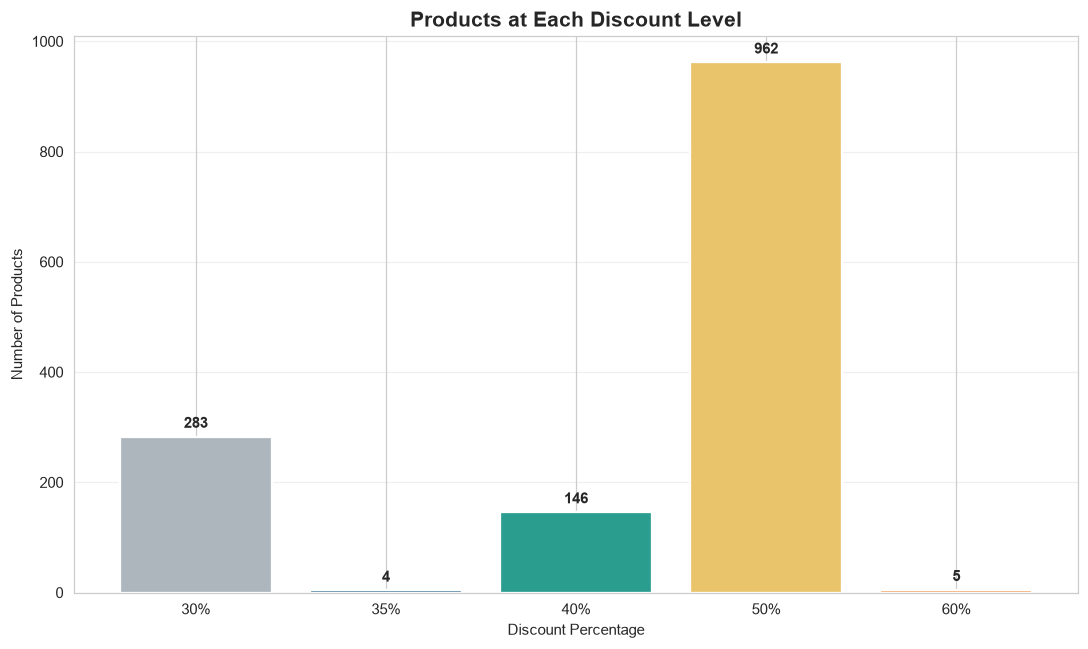

In [30]:
tier_counts = discounted["discount_pct"].value_counts().sort_index()

# Color palette
tier_colors = [
    "#ADB5BD",
    "#457B9D",
    "#2A9D8F",
    "#E9C46A",
    "#F4A261",
    "#E63946",
    "#6A0572"
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    [f"{int(x)}%" for x in tier_counts.index],
    tier_counts.values,
    color=tier_colors[:len(tier_counts)],
    edgecolor="white",
    linewidth=1.5
)

# Add product counts above bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Products at Each Discount Level",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Products")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "charts/chart1_discount_tiers.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Chart 2 — Sub-brand Discounting Behaviour

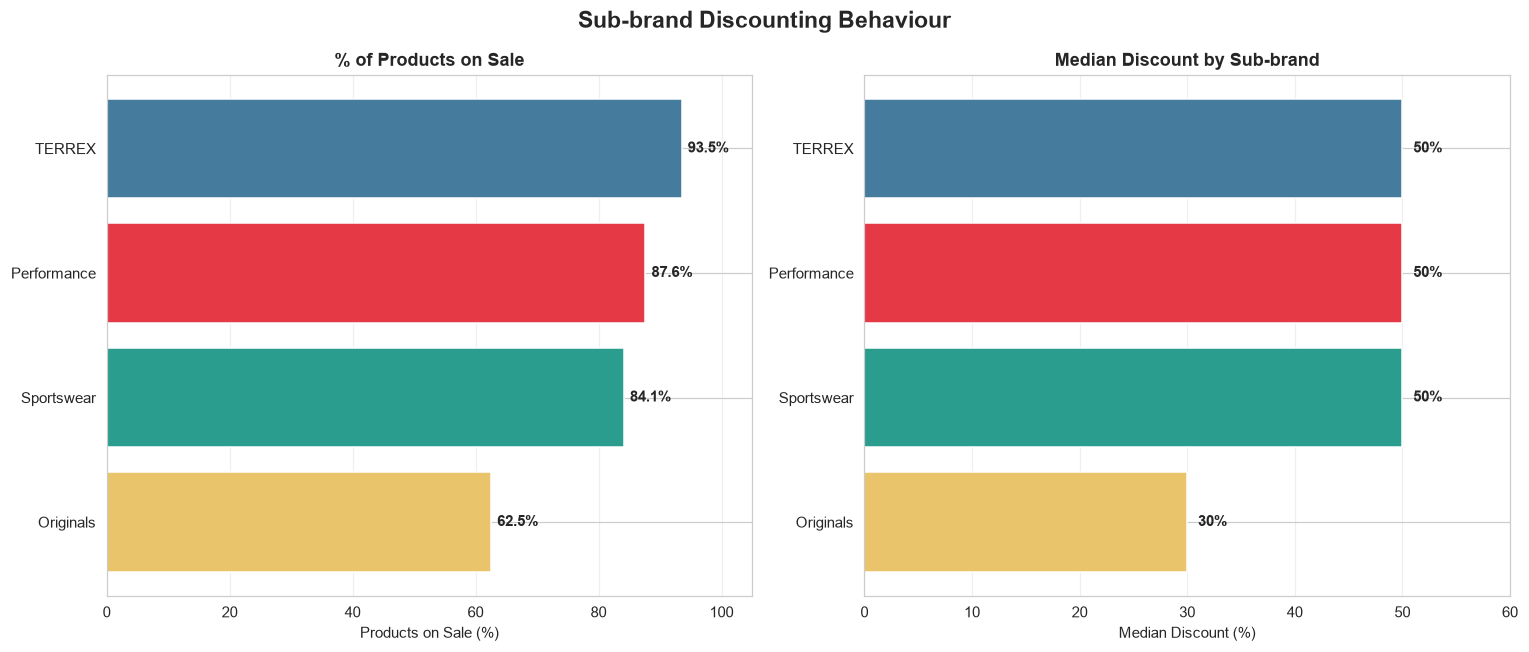

In [31]:
summary_plot = sub_brand_summary.sort_values("pct_on_sale")

colors = {
    "Originals": "#E9C46A",
    "Performance": "#E63946",
    "Sportswear": "#2A9D8F",
    "TERREX": "#457B9D"
}

bar_colors = summary_plot["sub_brand"].map(colors)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Percentage of products on sale
bars1 = axes[0].barh(
    summary_plot["sub_brand"],
    summary_plot["pct_on_sale"],
    color=bar_colors
)

for bar in bars1:
    axes[0].text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}%",
        va="center",
        fontweight="bold"
    )

axes[0].set_title("% of Products on Sale", fontweight="bold")
axes[0].set_xlabel("Products on Sale (%)")
axes[0].set_xlim(0, 105)
axes[0].grid(axis="x", alpha=0.3)


# Chart 2: Median discount
bars2 = axes[1].barh(
    summary_plot["sub_brand"],
    summary_plot["median_discount_pct"],
    color=bar_colors
)

for bar in bars2:
    axes[1].text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.0f}%",
        va="center",
        fontweight="bold"
    )

axes[1].set_title("Median Discount by Sub-brand", fontweight="bold")
axes[1].set_xlabel("Median Discount (%)")
axes[1].set_xlim(0, 60)
axes[1].grid(axis="x", alpha=0.3)


plt.suptitle(
    "Sub-brand Discounting Behaviour",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "charts/chart2_subbrand_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Chart 3 — Discount Behaviour Across Price Tiers

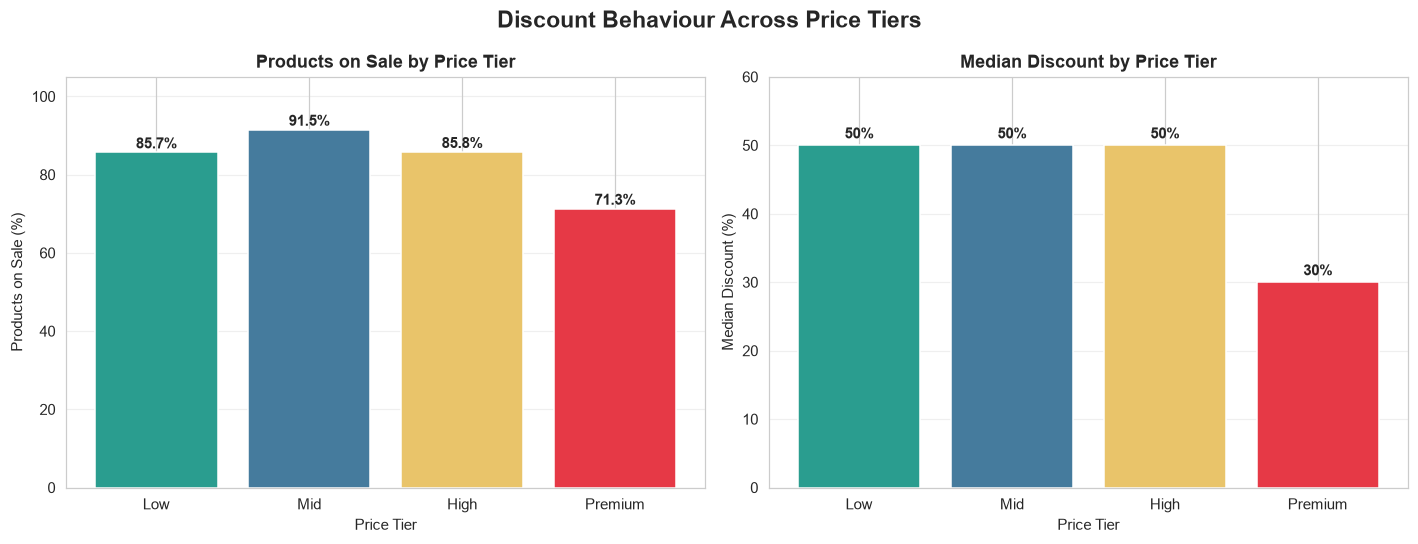

In [32]:
tier_order = ["Low", "Mid", "High", "Premium"]

tier_plot = tier_summary.reindex(tier_order).reset_index()

tier_colors = [
    "#2A9D8F",
    "#457B9D",
    "#E9C46A",
    "#E63946"
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))


# Left: Percentage of products on sale
bars1 = axes[0].bar(
    tier_plot["price_tier"],
    tier_plot["pct_on_sale"],
    color=tier_colors,
    edgecolor="white"
)

for bar in bars1:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}%",
        ha="center",
        fontweight="bold"
    )

axes[0].set_title("Products on Sale by Price Tier", fontweight="bold")
axes[0].set_xlabel("Price Tier")
axes[0].set_ylabel("Products on Sale (%)")
axes[0].set_ylim(0, 105)
axes[0].grid(axis="y", alpha=0.3)


# Right: Median discount percentage
bars2 = axes[1].bar(
    tier_plot["price_tier"],
    tier_plot["median_discount_pct"],
    color=tier_colors,
    edgecolor="white"
)

for bar in bars2:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.0f}%",
        ha="center",
        fontweight="bold"
    )

axes[1].set_title("Median Discount by Price Tier", fontweight="bold")
axes[1].set_xlabel("Price Tier")
axes[1].set_ylabel("Median Discount (%)")
axes[1].set_ylim(0, 60)
axes[1].grid(axis="y", alpha=0.3)


plt.suptitle(
    "Discount Behaviour Across Price Tiers",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "charts/chart3_price_tier_discount.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## **6. Key Findings**

**1. Discounts follow clear fixed tiers.**
Most discounted products are at **30%, 40%, or 50% off**, with 50% being the most common. This suggests that adidas uses standard discount levels across the catalogue.

**2. Originals follows a different discount pattern.**
Performance, Sportswear, and TERREX have a **50% median discount**, with around **88–95%** of products on sale. Originals has a lower **30% median discount**, with only **65%** of products on sale. This suggests a more conservative discounting strategy for Originals.

**3. Price has only a weak relationship with discount depth.**
The Pearson correlation is **r = -0.246**, showing a weak negative relationship. Higher-priced shoes tend to receive slightly smaller discounts, but price alone is not a strong predictor of discount percentage.

**4. The outliers are unusually low-discount products.**
The IQR method flagged **65 products** with unusually shallow discounts compared with others in the same sub-brand. These products may follow a different pricing strategy, but more data would be needed to understand the exact reason.

---

*Limitations: This analysis is based on a single-day snapshot of one product category on the adidas India website. Discount patterns may change with seasons and sale events. The analysis covers pricing behaviour only and does not include sales, inventory, cost, or profit-margin data.*